# Khai phá đồ thị IUH - 2026

### Lab 02. Ngày 22/01/2026. Sinh graph hoặc thao tác với graph có sẵn.

### Yêu cầu 1:
SV tải file data.txt về (mô tả mối quan hệ bạn bè giữa tập hợp những người trong CLB) và chạy các lệnh bên dưới, từ đó hãy thực hiện:
- Tính số đỉnh, số cạnh.
- In ma trận kề.
- In danh sách các đỉnh theo thứ tự tăng dần.
- Vẽ graph với label đỉnh theo từng kiểu sau đây: nx.draw, nx.draw_random, nx.draw_circular, nx.draw_spectral, nx.draw_spring

In [5]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
G = nx.read_edgelist("data.txt")

In [6]:
print("Số node: ", G.number_of_nodes())
print("Số cạnh: ", G.number_of_edges())
print("density: ", nx.density(G))

Số node:  30
Số cạnh:  158
density:  0.3632183908045977


In [7]:
#- In danh sách các đỉnh theo thứ tự tăng dần.
nodes_list = sorted([int(node) for node in G.nodes()])
print("Danh sách các đỉnh theo thứ tự tăng dần: ")
print(nodes_list)

Danh sách các đỉnh theo thứ tự tăng dần: 
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


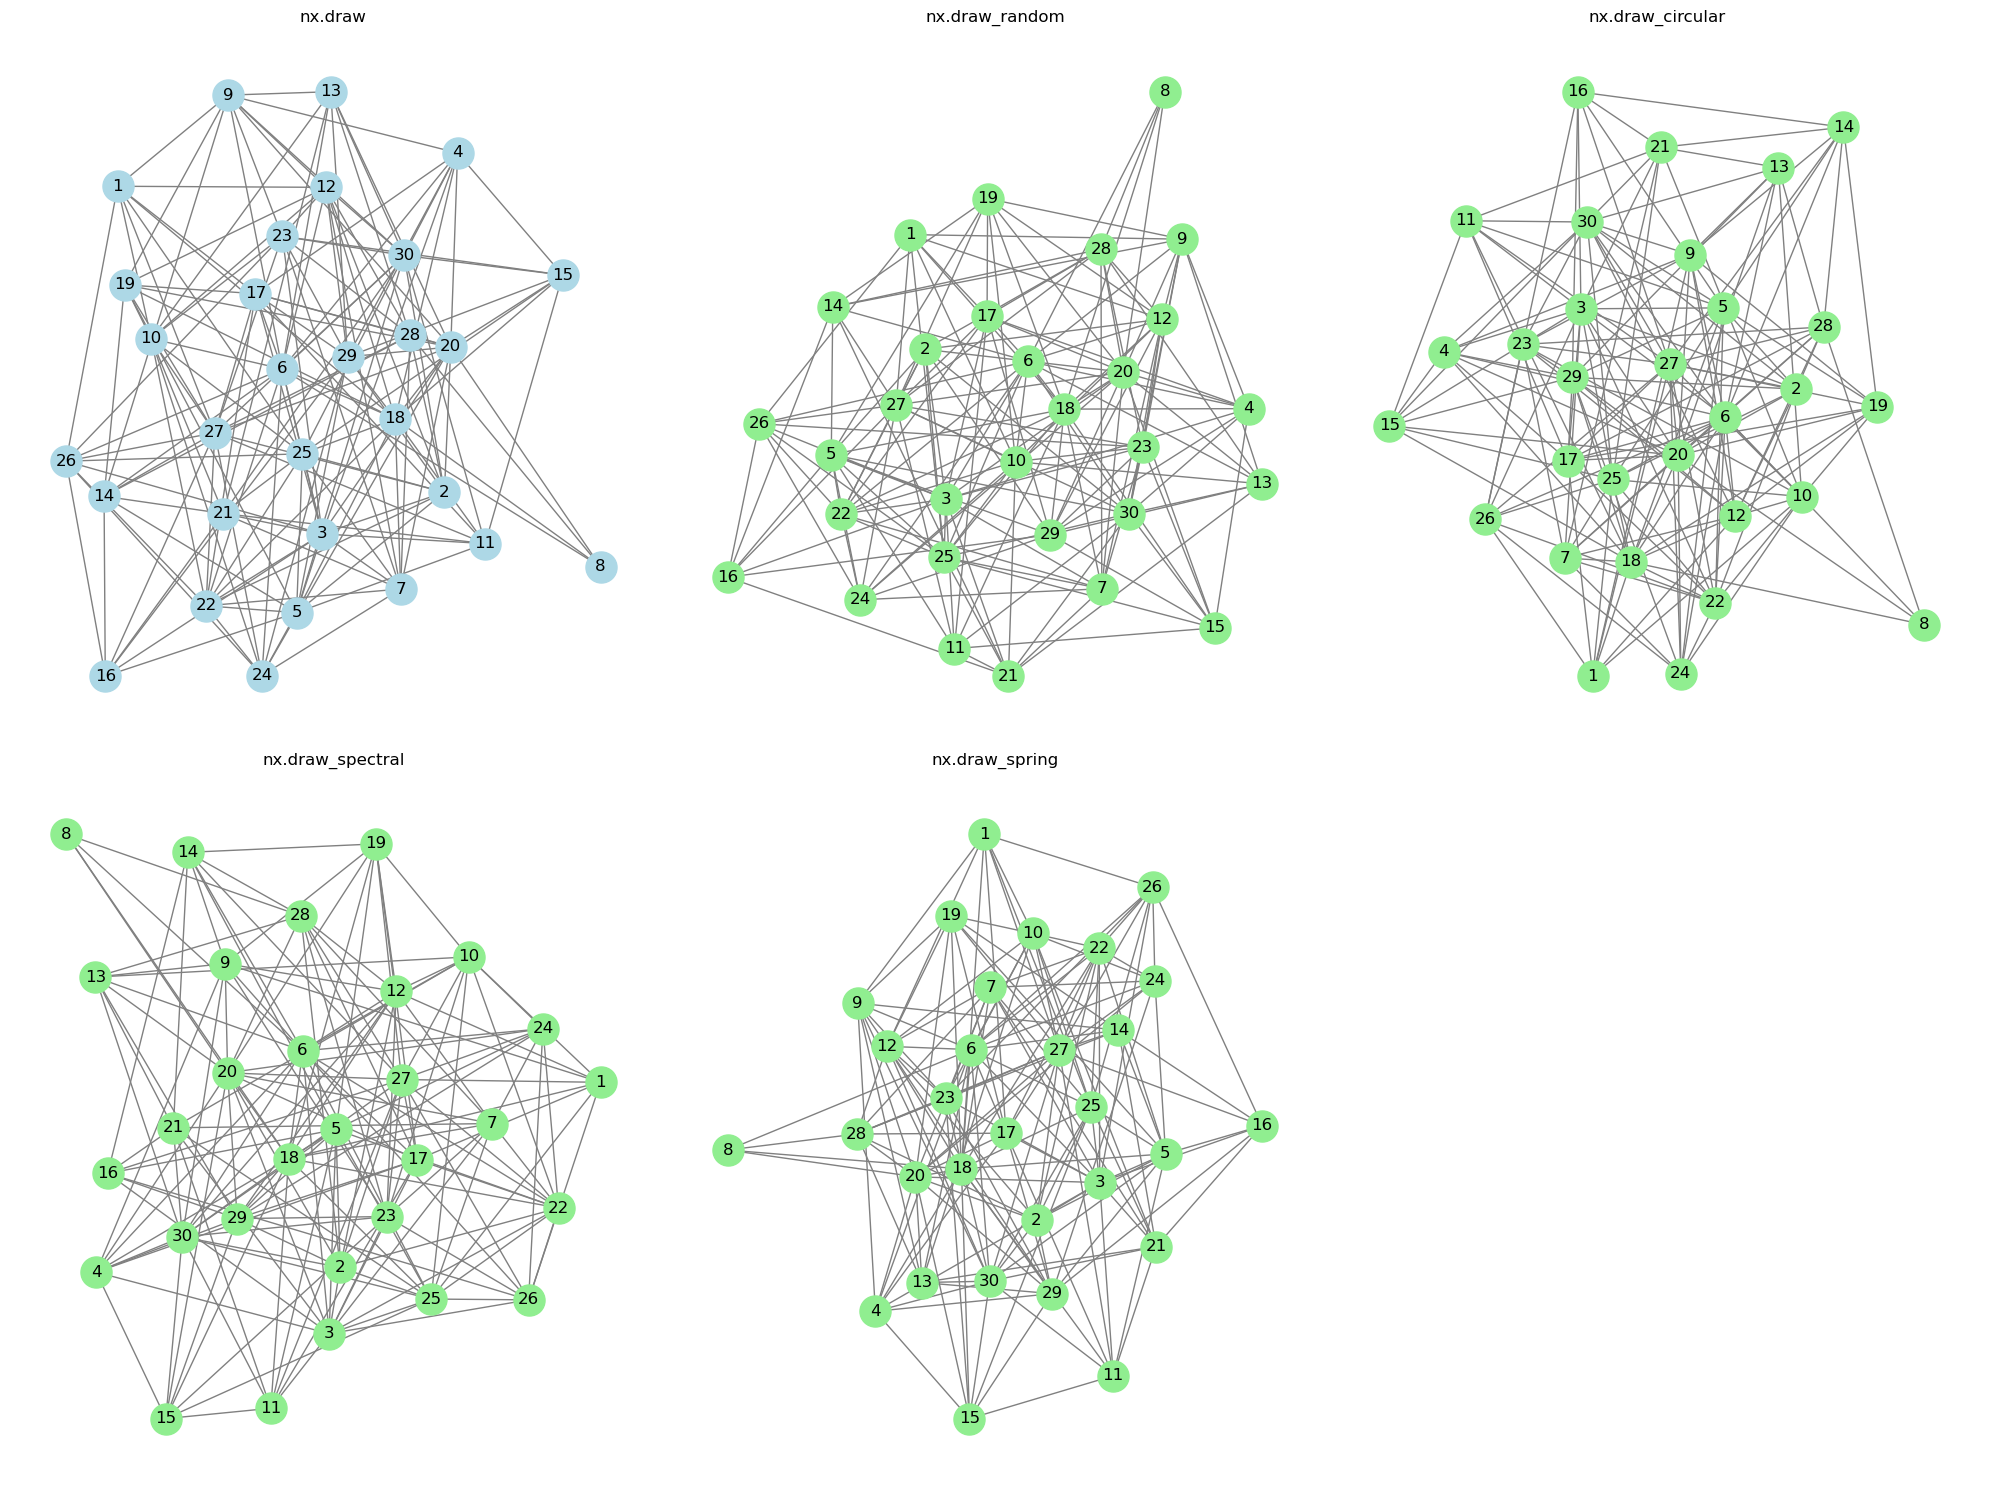

In [9]:
layouts = {
    "nx.draw": None,
    "nx.draw_random": nx.random_layout(G),
    "nx.draw_circular": nx.circular_layout(G),
    "nx.draw_spectral": nx.spectral_layout(G),
    "nx.draw_spring": nx.spring_layout(G)   
}
plt.figure(figsize=(20,15))
for i, (name, pos) in enumerate(layouts.items(),1):
    plt.subplot(2,3,i)
    plt.title(name)
    if name =="nx.draw":
        nx.draw(G,with_labels = True, node_color='lightblue',edge_color ='gray', node_size = 500)
    else:
        nx.draw(G, with_labels = True, node_color ='lightgreen', edge_color='gray', node_size =500)
plt.tight_layout()
plt.show()

### Yêu cầu 2: 
- Sinh ngẫu nhiên một ma trận kích thước $10 \times 10$ để làm ma trận liên thuộc của một graph có hướng $10$ đỉnh.
- Tạo graph có hướng $H$ từ ma trận trên.
- Thực hiện vẽ graph $H$ (có mũi tên) theo đoạn code bên dưới:

In [11]:
#CODE HERE
import networkx as nx
import json 
adj_matrix = np.random.randint(0,2, size=(10,10))
H = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

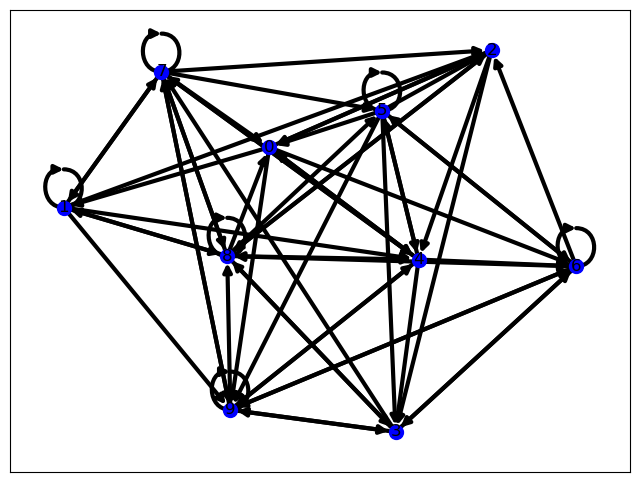

In [14]:
options = {
    'node_color': 'blue',
    'node_size': 100,
    'width': 3,
    'arrowstyle': '-|>',
    'arrowsize': 12,
}
plt.figure(figsize=(8, 6))
nx.draw_networkx(H, arrows=True, with_labels=True, **options)
plt.show()

- Tham khảo link sau đây để chuyển graph trên sang dạng Json, thử đọc lại graph từ file Json lưu lại được:: 

https://networkx.org/documentation/stable/reference/readwrite/json_graph.html

- Tham khảo link sau đây để chuyển graph trên sang dạng GML, thử đọc lại graph từ file GML lưu lại được:

https://networkx.org/documentation/stable/reference/readwrite/gml.html

In [15]:
#CODE HER
data = nx.node_link_data(H)
with open("graph_H.json","w") as f:
    json.dump(data,f)
nx.write_gml(H, "graph_H.gml")

C:\Users\Lenovo\anaconda3\Lib\site-packages\networkx\readwrite\json_graph\node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


- Tham khảo ý tưởng sau đây để in graph với đỉnh có màu, trong đó đỉnh bậc chẵn thì màu xanh, bậc lẻ thì màu đỏ.

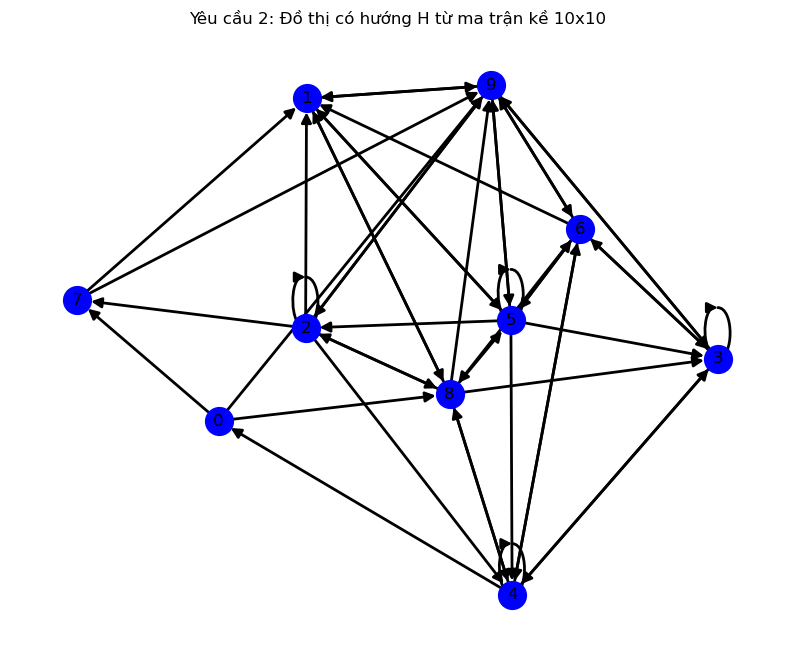

In [21]:
colors = []
for v in G.nodes:
    if S[v] % 2 == 1:
        colors.append('green')
    else:
        colors.append('red')

nx.draw(G, with_labels=True, node_color=colors)
plt.show()

### Yêu cầu 3: 
- Viết hàm sinh ngẫu nhiên một graph với $n$ đỉnh và desity là $p$. Từ đó so sánh với hàm erdos_renyi_graph và gnm_random_graph có sẵn của thư viện.
- Vẽ tất cả các graph sau đây bằng cách tạo và vẽ graph ứng với thư viện có sẵn: cycle_graph, path_graph, star_graph, complete_graph, wheel_graph, full_rary_tree, grid_2d_graph, ego_graph, windmill_graph.

In [19]:
#CODE HERE
import networkx as nx
G = nx.DiGraph()
G.add_weighted_edges_from([(0, 1, 2), (1, 2, 2), (2, 0, 1), (1, 4, 2), (4, 0, 5)])
nx.negative_edge_cycle(G)
[4, 0, 1, 4]

[4, 0, 1, 4]

### Yêu cầu 4:
- Cho danh sách tên người sau đây: Vũ, Tuấn, Trọng, Hưng, Hà, Tùng, My, Linh, Huyền, Bình. Hãy sử dụng hàm đã viết ở câu trên để sinh ra một graph với $p=0.7$, trong đó các đỉnh ứng với tên $10$ người.
- Đọc nội dung lý thuyết sau đây và trả lời các câu hỏi: tính số đường đi từ Vũ đến Hà với độ dài đường đi là $5$, tính số bộ ba người đôi một quen nhau, kiểm tra tính liên thông của graph này.

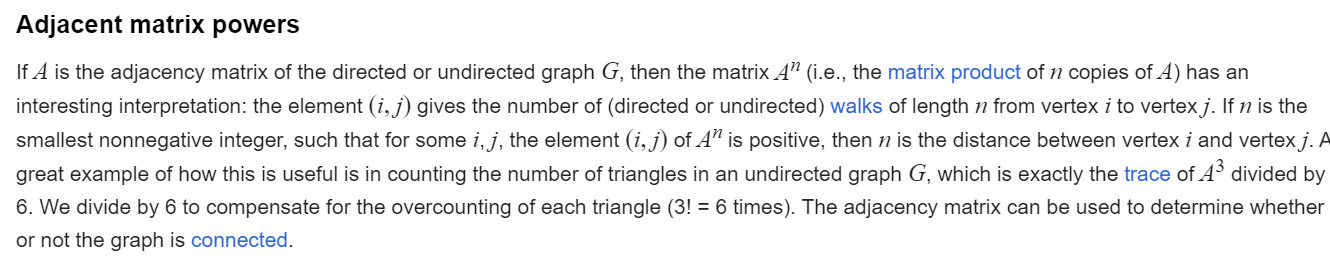

In [ ]:
#CODE HERE